# Исследование рынка общественного питания Москвы

- Автор: Постнова Ю. Д. 
- Дата:23.01.2026

## Цель и задачи  

**Цель:** Целью данного исследования является анализ рынка заведений общественного питания Москвы с целью выявления ключевых особенностей рынка и факторов, которые могут повлиять на выбор формата, расположения и ценового сегмента заведения для инвесторов фонда Shut Up and Take My Money.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - Изучить данные более детально;
    - Проанализировать распределение заведений по категориям и районам Москвы;
    - Исследовать соотношение сетевых и несетевых заведений в целом и в разрезе категорий;
    - Проанализировать количество посадочных мест и выявить значения для различных форматов заведений;
    - Изучить распределение рейтингов заведений;
    - Определить факторы, наиболее связанные с рейтингом заведений;
    - Выявить топ-15 популярных сетей в Москве и проанализировать их характеристики;
    - Исследовать зависимость среднего чека заведений от их расположения относительно центра города;
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` —  информация о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.;
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    и так далее;
    
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `rest_info` и `rest_price`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `rest_info` и `rest_price`.


In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
#from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные rest_info и rest_price
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим информацию о датафрейме
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов приведены к единому виду snake case.
- Представленные данные содержат числовые значения и хранятся в типах данных `int64` или `float64` и значения типа `object`. Значения в столбце `chain` представлены целыми числами. Они показывают является ли заведение сетевым 1 или 0 — размерность этих данных можно оптимизировать.
- Пропуски содержатся только в столбцах `hours` и `seats`, доля пропусков в `seats` является значительной. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Числовые признаки (`rating`, `seats`) представлены корректно, но требуют дополнительной проверки на выбросы
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о ценовой категории и среднем чеке. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов приведены к единому виду snake case.
- Типы данных соответствуют содержимому. 
- Пропуски содержатся в столбцах `price`,`avg_bill`, `middle_avg_bill`  и особенно `middle_coffee_cup`.
- Данные о среднем чеке представлены не для всех заведений, что необходимо учитывать при дальнейшем анализе цен.
- Значения в столбцах соответствуют описанию.


---

---

### Промежуточный вывод

В рамках первого этапа были загружены и изучены два датасета с информацией о заведениях общественного питания Москвы.

Данные соответствуют заявленному описанию и имеют удовлетворительное качество для проведения исследовательского анализа. На этапе предобработки следует уделить внимание:

- Обработке пропущенных значений, особенно в ценовых показателях и количестве посадочных мест;

- Оптимизации типов данных;

- Проверке и удалению возможных дубликатов;


На следующем этапе будет выполнена предобработка данных и их подготовка к исследовательскому анализу.

### Подготовка единого датафрейма

Для дальнейшего анализа необходимо объединить информацию о заведениях общественного питания и данные о ценовой категории и среднем чеке в один датафрейм.
Датасет `rest_info` содержит основной перечень заведений Москвы, a датасет `rest_price`содержит информацию о ценовых характеристиках только для части объектов.

Объединение выполнено по столбцу `id`, который является уникальным идентификатором заведения в обоих датасетах. Важно сохранить все заведения из датасета `rest_info`, даже если для них отсутствует информация о ценах. Это делает дальнейший исследовательский анализ более корректным, поэтому выбираем тип соединения `left join`.

In [7]:
# Соединяем данные в единый датафрейм df
df = rest_info.merge(rest_price, on='id', how='left')

In [8]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Данные соединены, и информация обо всех заведениях сохранилась.

---

## 2. Предобработка данных

На данном этапе данные подготавливаются к исследовательскому анализу:

- Проверяется корректность типов данных и при необходимости выполняется их преобразование;

- Анализируются пропущенные значения, формулируются гипотезы их появления и выбирается способ обработки;

- Проводится поиск и удаление явных и неявных дубликатов, включая нормализацию текстовых признаков;

- Создается дополнительный признак is_24_7, отражающий круглосуточный режим работы заведения.

In [9]:
# Оптимизируем целочисленный тип данных
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

In [10]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

**Проверяем наличие пропусков в данных**

Изучаем пропущенные значения в данных: считаем их количество в каждом столбце датафрейме, изучаем данные с пропущенными значениями и далаем гипотезы их появления. Проводим обработку пропущенных значений.

In [11]:
# Выводим количество пропущенных строк в датафрейме
missing_count = df.isna().sum().sort_values(ascending=False)
missing_count

middle_coffee_cup    7871
middle_avg_bill      5257
price                5091
avg_bill             4590
seats                3611
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
dtype: int64

In [12]:
# Подсчитываем долю строк с пропусками
missing_share = (df.isna().sum() / df.shape[0]).sort_values(ascending=False)
missing_share

middle_coffee_cup    0.936355
middle_avg_bill      0.625387
price                0.605639
avg_bill             0.546039
seats                0.429574
hours                0.063764
id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
rating               0.000000
chain                0.000000
dtype: float64

В датафрейме `df` обнаружены пропуски в столбцах `hours`, `seats`, `price`, `avg_bill`,`middle_avg_bill`,`middle_coffee_cup`. Количество пропусков достаточно большое, чтобы их просто удалить.

Пропуски в этих столбцах могут быть вызваны:
- `hours`: отсутствие данных о режиме работы на момент сбора информации или заведение временно закрыто / не обновило данные.
- `seats`: количество посадочных мест часто не указывается для небольших заведений/заведений формата "to-go". Отсутствие данных не означает отсутствие посадочных мест, поэтому удалять строки нецелесообразно.
- `price`, `avg_bill`,`middle_avg_bill`,`middle_coffee_cup`: пропуски объясняются тем, что ценовая информация доступна не для всех заведений, а `middle_avg_bill` и `middle_coffee_cup` заполняются только при наличии  определённого формата строки в avg_bill.

С учётом характера данных были приняты следующие решения:

- Строки с пропусками не удаляются, так как это привело бы к значительной потере данных;

- Пропуски в числовых столбцах оставлены без заполнения, чтобы не вносить искажения в распределения;

- Пропуски в категориальных признаках `price` также оставлены, так как отсутствие информации само по себе является значимым фактом.

**Явные и неявные дубликаты в данных**

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:


In [13]:
# Проверяем полные дубликаты
df.duplicated().sum()

0

Явных дубликатов строк в датафрейме не обнаружено. 

In [14]:
# Проверяем неявные дубликаты в датафрейме
df.duplicated(subset='id').sum()

0

Значения по `id` заведений уникальны, каждая строка соответствует уникальному заведению

Проверим неявные дубликаты — поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в дополнительных текстовых столбцах с названием и адресом заведения.

In [15]:
df['name_norm'] = df['name'].str.lower()
df['address_norm'] = df['address'].str.lower()

In [16]:
# Проверим дубликаты по сочетанию названия и адреса:
duplicates = df.duplicated(subset=['name_norm', 'address_norm']).sum()
duplicates

4

In [17]:
# Выведем на экран неявные дубликаты
df[df.duplicated(subset=['name_norm', 'address_norm'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,name_norm,address_norm
189,072032ce16dc47bfbc63b672c75bd371,Кафе,кафе,"Москва, парк Ангарские Пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,NaN,NaN,NaN,NaN,NaN,кафе,"москва, парк ангарские пруды"
215,897ddbc6746c4388b19dc8a9fcdbb488,Кафе,кафе,"Москва, парк Ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN,кафе,"москва, парк ангарские пруды"
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188.0,NaN,NaN,NaN,NaN,more poke,"москва, волоколамское шоссе, 11, стр. 2"
1511,a69f018d5c064873a3b491b0121bc1b4,More Poke,ресторан,"Москва, Волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN,more poke,"москва, волоколамское шоссе, 11, стр. 2"
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня Клешни и Хвосты,ресторан,"Москва, проспект Мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150.0,NaN,NaN,NaN,NaN,раковарня клешни и хвосты,"москва, проспект мира, 118"
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня Клешни и хвосты,"бар,паб","Москва, проспект Мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN,раковарня клешни и хвосты,"москва, проспект мира, 118"
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да Выпечка,булочная,"Москва, Ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276.0,NaN,NaN,NaN,NaN,хлеб да выпечка,"москва, ярцевская улица, 19"
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"Москва, Ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN,хлеб да выпечка,"москва, ярцевская улица, 19"


Обнаружены 4 строки с полностью совпадающими названием и адресом заведения.
Такие записи однозначно относятся к одному и тому же объекту общественного питания и являются неявными дубликатами, поэтому было принято решение удалить дубликаты, оставив первую запись.

In [18]:
#Удаляем неявные дубликаты 
df = df.drop_duplicates(subset=['name_norm', 'address_norm'], keep='first', inplace=False) 

In [19]:
#Удаляем вспомогательные столбцы
df = df.drop(columns=['name_norm', 'address_norm'])

In [20]:
#Доля удалённых данных от исходного датасета
duplicates/8406

0.0004758505829169641

Удалённая доля (0.048%) данных является незначительной и не оказывает существенного влияния на репрезентативность датасета.

In [21]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['district', 'category', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



Других неявных дубликатов (по различиям в написании категорий, районов и ценовых сегментов) в данных не обнаружено.

---

Таким образом, в данных отсутствуют полные дубликаты строк.
Идентификаторы заведений уникальны.
Обнаружены 4 неявных дубликата по совпадению названия и адреса заведения.
Поскольку такие записи относятся к одному и тому же объекту, дубликаты были удалены.
Удалённая доля данных составила менее 0.05% и не оказывает существенного влияния на результаты анализа.

- Для дальнейшей работы создали столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [22]:
df['is_24_7'] = df['hours'].str.contains('круглосуточно|24/7|ежедневно.*00:00–24:00|00:00–24:00.*ежедневно', case=False, na=False)

In [23]:
#Проверим получившийся датафрейм, выведем первые 5 строк
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


---

### Промежуточный вывод

На этапе предобработки данных была проведена комплексная подготовка датафрейма к исследовательскому анализу.

В ходе работы:

- Проверена корректность типов данных и оптимизирован тип признака `chain`;

- Проанализированы пропущенные значения: установлено, что пропуски носят неслучайный характер и связаны с особенностями заполнения информации о режиме работы, количестве посадочных мест и ценовых характеристиках заведений;

- Принято решение не удалять строки с пропусками и не заполнять их искусственно, чтобы избежать искажения распределений и сохранить максимальный объём данных;

- Выполнена проверка данных на явные и неявные дубликаты: обнаружены и удалены 4 строки-дубликата по совпадению названия и адреса заведения, что составляет около 0,048% от общего объёма данных и не оказывает существенного влияния;

- Проверена корректность категориальных признаков — ошибок и несоответствий не выявлено;

- Создан дополнительный аналитический признак `is_24_7`, отражающий круглосуточный режим работы заведений.

В результате предобработки сформирован очищенный и структурированный датафрейм, пригодный для проведения исследовательского анализа данных.

## 3. Исследовательский анализ данных

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [24]:
# Проверяем распределение данных по значениям в столбце
print(f'Распределение данных по значениям столбца category:')
print(df['category'].value_counts())
print(f'\nДоля распределения:')
print(df['category'].value_counts(normalize=True))

Распределение данных по значениям столбца category:
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Доля распределения:
кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64


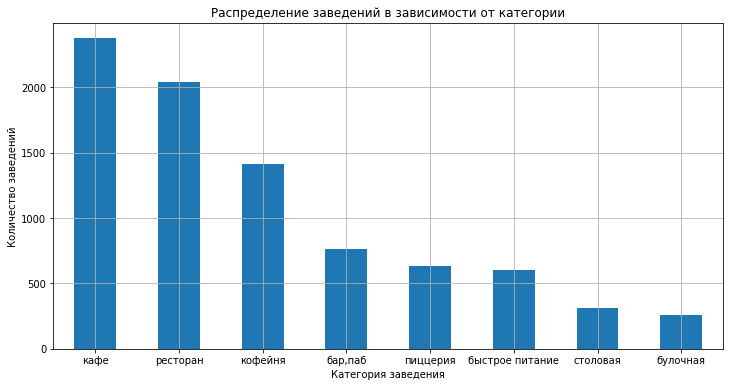

In [25]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
df['category'].value_counts().plot(
               kind='bar', 
               rot=0, 
               legend=False, 
               title=f'Распределение заведений в зависимости от категории'
)

# Оформляем график
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

Наиболее распространены кафе (28.28%), рестораны (24.3%) и кофейни (16.82%).

Наименее — столовая (3.75%) и булочная(3.05%).

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [26]:
# Посчитаем общее распределение по районам
print('Распределение данных по значениям столбца district:')
print(df['district'].value_counts())
print('\nДоля распределения:')
print(df['district'].value_counts(normalize=True))

Распределение данных по значениям столбца district:
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Доля распределения:
Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.04867

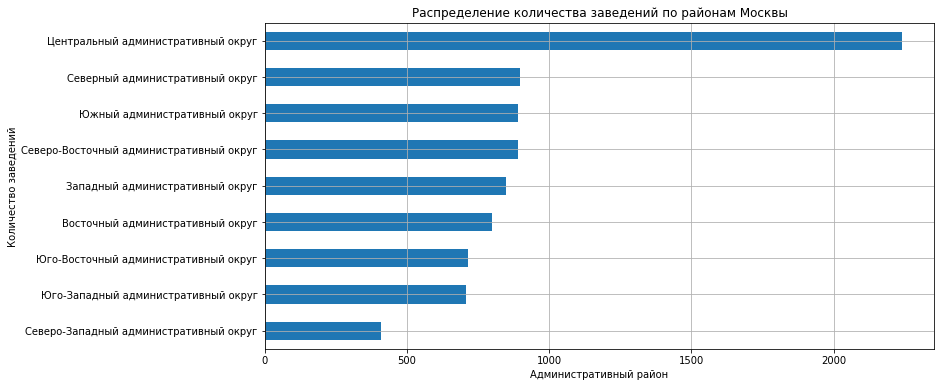

In [27]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
df['district'].value_counts().sort_values(ascending=True).plot(
               kind='barh', 
               rot=0, 
               legend=False, 
               title=f'Распределение количества заведений по районам Москвы'
)

# Оформляем график
plt.xlabel('Административный район')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

Центральный административный округ — самый насыщенный по количеству заведений. В нем сосредоточено 26.68% всех заведений. Самый малочисленный по количеству заведений - Северо-Западный административный округ (4.87%).

Далее рассмотрим распределение заведений каждой категории в Центральном административном округе Москвы:

In [28]:
# Распределение категорий в Центральном административном округе
print('Распределение категорий в Центральном административном округе:')
df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts()

Распределение категорий в Центральном административном округе:


ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

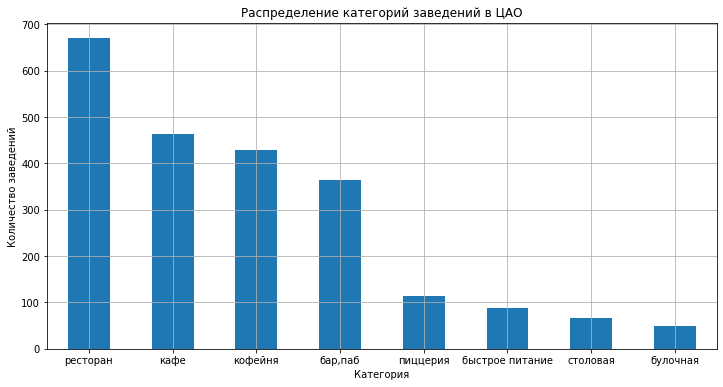

In [29]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
df.loc[df['district'] == 'Центральный административный округ']['category'].value_counts().plot(
               kind='bar', 
               rot=0, 
               legend=False, 
               title=f'Распределение категорий заведений в ЦАО'
)

# Оформляем график
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

В Центральном административном округе Москвы преобладают рестораны и кафе, наименьшее количество - столовые и булочные.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

In [30]:
#Посчитаем количество сетевых (chain=1) и несетевых (chain=0) заведений
print('Количество несетевых и сетевых заведений:')
print(df['chain'].value_counts())

print('\nДоли:')
print(df['chain'].value_counts(normalize=True))

Количество несетевых и сетевых заведений:
0    5199
1    3203
Name: chain, dtype: int64

Доли:
0    0.618781
1    0.381219
Name: chain, dtype: float64


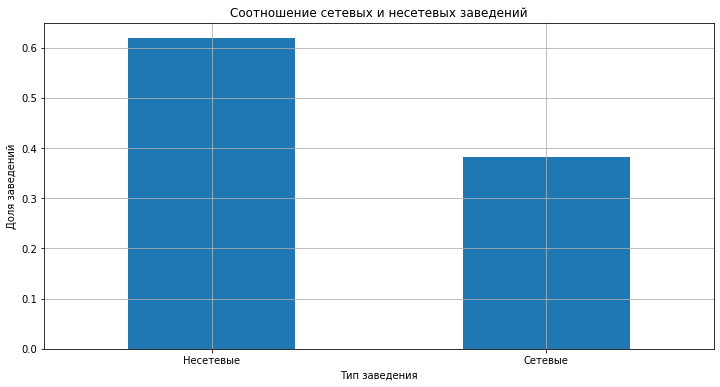

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
df['chain'].value_counts(normalize=True).plot(
               kind='bar', 
               rot=0, 
               legend=False,
               title=f'Соотношение сетевых и несетевых заведений'
)

# Оформляем график
plt.xlabel('Тип заведения')
plt.ylabel('Доля заведений')
plt.xticks([0, 1], ['Несетевые', 'Сетевые'])
plt.grid()
plt.show()

Большинство заведений несетевые (61.88%).

In [32]:
# Рассчитаем долю сетевых заведений в каждой категории
category_stats = df.groupby('category')['chain'].agg(['count', 'sum'])
category_stats['pct_chain'] = category_stats['sum'] / category_stats['count'] * 100

print('\nДоля сетевых заведений по категориям:')
print(category_stats[['count', 'sum', 'pct_chain']].round(2))


Доля сетевых заведений по категориям:
                 count    sum  pct_chain
category                                
бар,паб            764  168.0      21.99
булочная           256  157.0      61.33
быстрое питание    603  232.0      38.47
кафе              2376  779.0      32.79
кофейня           1413  720.0      50.96
пиццерия           633  330.0      52.13
ресторан          2042  729.0      35.70
столовая           315   88.0      27.94


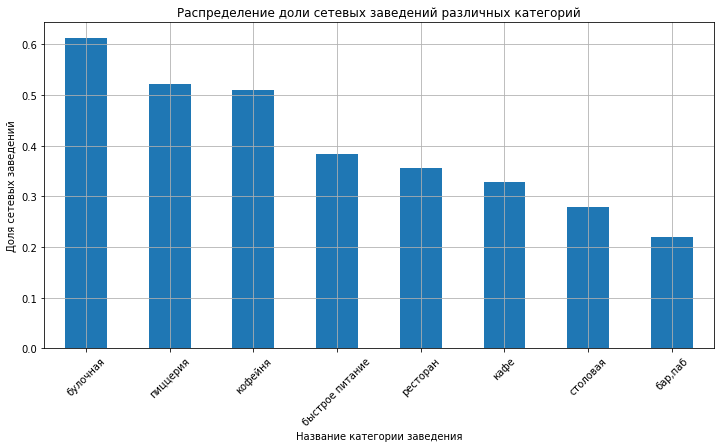

In [33]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
grouped = df.groupby('category')['chain'].mean().sort_values(ascending=False)

grouped.plot(kind='bar', 
            rot=45, 
            legend=False, 
            title=f'Распределение доли сетевых заведений различных категорий'
)

# Оформляем график
plt.xlabel('Название категории заведения')
plt.ylabel('Доля сетевых заведений')
plt.grid()
plt.show()

**Общее соотношение по всем данным:**
- Несетевых заведений больше, чем сетевых
- 61.88% всех заведений являются несетевыми (5 199 заведений)
- 38.12% являются сетевыми (3 203 заведения)

**Анализ сетевых заведений по категориям:**
- Чаще всего сетевыми являются: булочные (61.33%), пиццерии (52.13%), кофейни (50.96%)
- Категории с наименьшей долей сетевых заведений: столовые(27.94%), бары/пабы (21.99%) 

**Итоговый вывод**

Рынок заведений Москвы преимущественно состоит из независимых заведений (61.88%), однако в некоторых категориях (булочные, пиццерии, кофейни), преобладают сетевые заведения.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [34]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

- Медианное количество посадочных мест — 75;

- 50% заведений имеют от 40 до 140 посадочных мест;

- Минимальное значение — 0, максимальное — 1288;

- Среднее значение (108) заметно выше медианы, что указывает на асимметрию распределения вправо.

Для выявления аномальных значений был использован метод межквартильного размаха (IQR).

In [35]:
# Проверка на выбросы
# Вычисляем квартили Q1 и Q3
Q1 = df['seats'].quantile(0.25)
Q3 = df['seats'].quantile(0.75)

# Вычисляем межквартильный размах IQR
IQR = Q3 - Q1

# Определяем верхний порог для выбросов
upper_bound = Q3 + 1.5 * IQR

print(f'Верхний порог выбросов: {upper_bound}')

Верхний порог выбросов: 290.0


In [36]:
# Количество выбросов
outliers = df[(df['seats'] > upper_bound)]
print(f"\nКоличество выбросов: {len(outliers)}")


Количество выбросов: 318


In [37]:
# Самые большие значения
print("Топ-10 заведений с наибольшим количеством мест:")
print(df.nlargest(10, 'seats')[['name', 'category', 'seats']])

Топ-10 заведений с наибольшим количеством мест:
                    name  category   seats
6518         DelonixCafe  ресторан  1288.0
6524           Ян Примус  ресторан  1288.0
6574              Мюнгер  пиццерия  1288.0
6641    One Price Coffee   кофейня  1288.0
6658              ГудБар   бар,паб  1288.0
6684     Пивной ресторан   бар,паб  1288.0
6690      Японская кухня  ресторан  1288.0
6771               Точка      кафе  1288.0
6807  Loft-cafe академия      кафе  1288.0
6808        Яндекс Лавка  ресторан  1288.0


У значительного числа заведений максимальное значение равно 1288 посадочных мест — вне зависимости от категории.

С высокой вероятностью значение 1288 является:

- либо значением-индикатором пропусков;

- либо ошибкой заполнения данных;


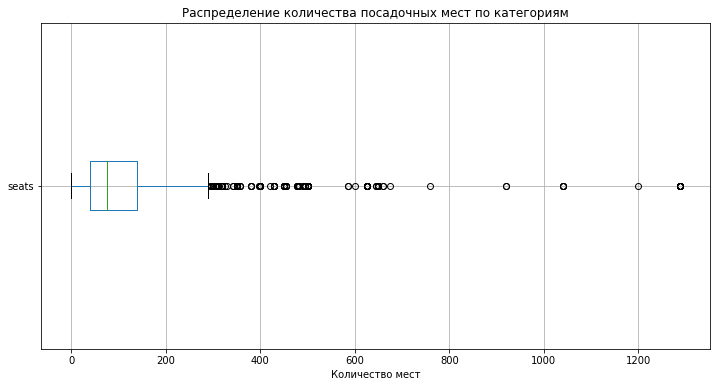

In [38]:
plt.figure(figsize=(12, 6))

# Строим диаграмму размаха значений в столбце seats
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение количества посадочных мест по категориям')
plt.xlabel('Количество мест')
plt.show()

- Основная масса значений сосредоточена ниже 200 мест;

- Присутствует длинный «хвост» вправо, сформированный аномальными значениями;

- Выбросы существенно искажают масштаб распределения.

В качестве типичного значения количества посадочных мест по категориям была выбрана медиана, так как она устойчива к выбросам.

In [39]:
median_seats = df.groupby('category')['seats'].median()
median_seats

category
бар,паб            82.0
булочная           50.0
быстрое питание    65.0
кафе               60.0
кофейня            80.0
пиццерия           55.0
ресторан           86.0
столовая           75.5
Name: seats, dtype: float64

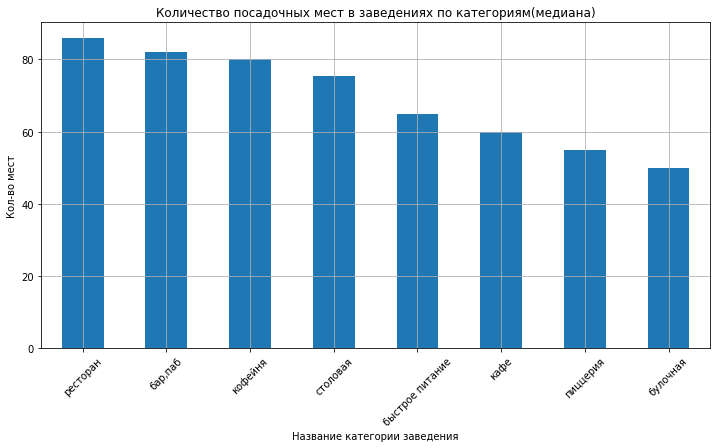

In [40]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 6))

# Строим столбчатую диаграмму 
median_seats = df.groupby('category')['seats'].median().sort_values(ascending=False)

median_seats.plot(kind='bar', 
            rot=45, 
            legend=False, 
            title=f'Количество посадочных мест в заведениях по категориям(медиана)'
)

# Оформляем график
plt.xlabel('Название категории заведения')
plt.ylabel('Кол-во мест')
plt.grid()
plt.show()

- Рестораны и бары/пабы имеют наибольшую вместимость, что соответствует их формату
- Булочные имеют наименьшую вместимость, так как часто ориентированы на вынос
- Кофейни имеют относительно высокую медианную вместимость (80 мест)


Выбросы не были удалены, так как могут нести дополнительную информацию

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [41]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца rating:')
df['rating'].describe()

Статистические показатели столбца rating:


count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

- Средний рейтинг заведений — 4.23;

- Медианный рейтинг — 4.3;

- 50% заведений имеют рейтинг в диапазоне от 4.1 до 4.4;

- Минимальный рейтинг — 1.0, максимальный — 5.0.

- Распределение рейтингов смещено в сторону высоких значений.

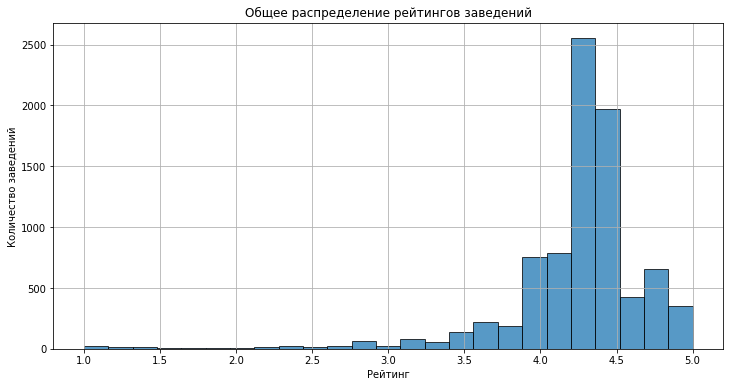

In [42]:
plt.figure(figsize=(12, 6))

# Строим гистограмму общих значений рейтинга
df['rating'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Общее распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

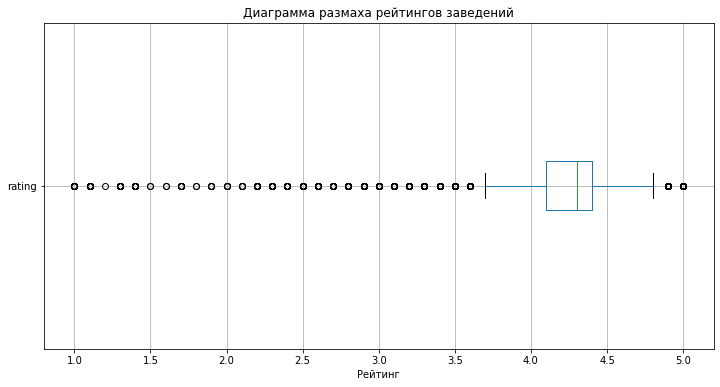

In [43]:
#Диаграмма размаха рейтингов
plt.figure(figsize=(12, 6))

# Строим диаграмму размаха значений в столбце rating
df.boxplot(column='rating', vert=False)

# Добавляем заголовок и метки оси
plt.title('Диаграмма размаха рейтингов заведений')
plt.xlabel('Рейтинг')
plt.show()

Выбросы присутствуют в левой части распределения (низкие рейтинги), однако в целом оценки достаточно однородны и сосредоточены в узком диапазоне высоких значений.

**Распределение рейтингов по категориям заведений**

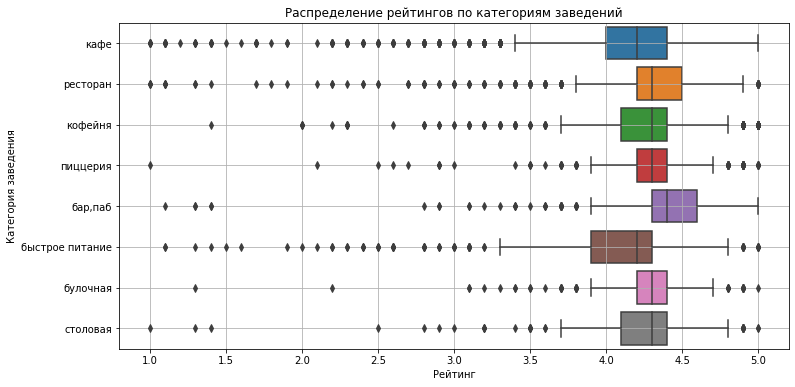

In [44]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='rating',
    y='category'
)

# Добавляем заголовок и метки оси
plt.title('Распределение рейтингов по категориям заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Категория заведения')
plt.grid()
plt.show()

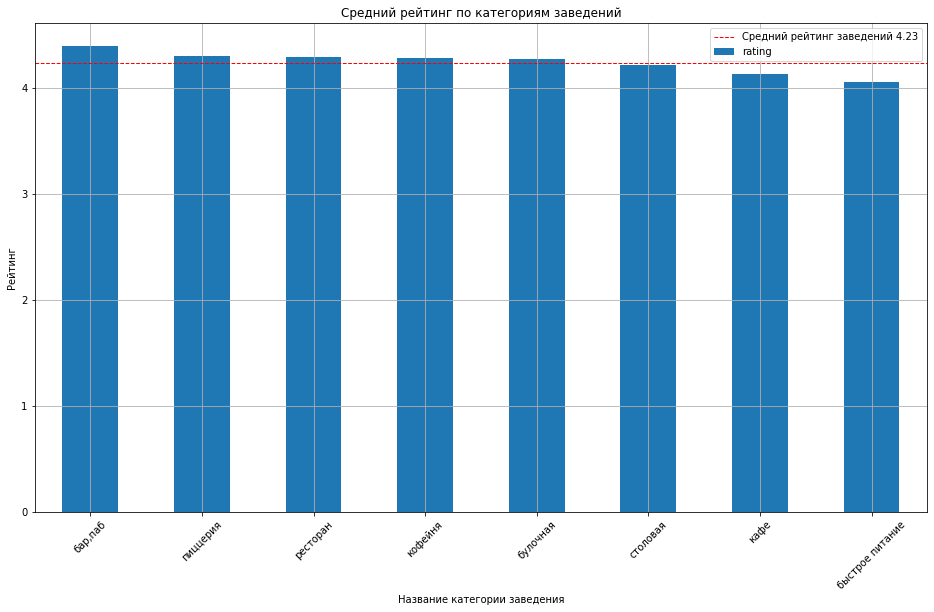

In [45]:
plt.figure(figsize=(16, 9))

# Строим столбчатую диаграмму cреднего рейтинга по категориям
mean_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

mean_rating.plot(kind='bar', 
            rot=45, 
            legend=False, 
            title=f'Средний рейтинг по категориям заведений'
)

# Рассчитываем среднее рейтинга
mean_rating_all = df['rating'].mean()
# Наносим на график линию со средним значением рейтига
plt.axhline(mean_rating_all, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг заведений {round(mean_rating_all,4)}')


# Оформляем график
plt.xlabel('Название категории заведения')
plt.ylabel('Рейтинг')
plt.grid()
plt.legend()
plt.show()

In [46]:
mean_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)
mean_rating

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290402
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124285
быстрое питание    4.050249
Name: rating, dtype: float64

- Средние рейтинги по категориям различаются незначительно — разброс составляет десятые доли балла.

- Наиболее высокие средние рейтинги: бар/паб, пиццерия, ресторан  
- Чуть более низкие: кофейня, булочная
- Самый низкий рейтинг, ниже среднего по всем категориям: столовая, кафе, быстрое питание.

Общий средний рейтинг заведений (обозначен на графике пунктирной линией) служит ориентиром: категории, находящиеся выше этой линии, можно считать относительно более успешными с точки зрения оценок.

В целом, распределение рейтингов по категориям достаточно плотное (разница менее 0.35 балла), что говорит о высоком уровне качества заведений независимо от формата.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

Чтобы понять, существует ли связь между данными, используем матрицы корреляции для признаков в данных. Для задачи важен столбец `rating`, поэтому будем изучать взаимосвязи данных в этом столбце с другими признаками.


Рассчитаем матрицу корреляции phi_k для данных о данных рынка заведений общественного питания Москвы. Для составления матрицы корреляции были отобраны данные, которые могут влиять на рейтиг заведения: ккатегория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. 

In [47]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'rating', 'chain', 'seats',
                         'price', 'is_24_7']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

AttributeError: 'DataFrame' object has no attribute 'phik_matrix'

Нас интересует связь рейтига с другими данными, поэтому на экран был выведен только столбец `rating` итоговой матрицы корреляции `correlation_matrix`.


- Наибольшая корреляция рейтинга наблюдается с ценовой категорией заведений (`0.22`), административным районом заведений (`0.2`) и категорийе заведения (`0.19`). Для остальных признаков коэффициент корреляции снижается с `0.15` до `0`.
- Количество посадочных мест `seats` не демонстрирует связи с рейтингом — коэффициент корреляции равен 0, что говорит об отсутствии зависимости.

Важно помнить, что `phi_k` сообщает только о наличии связи между данными. На сам характер связи коэффициент `phi_k` не указывает.

Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

In [ ]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5,
            cbar=False 
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Корреляция признаков с рейтингом')

# Выводим график
plt.show()

Теперь корреляция между оттоком клиентов и другими признаками наглядно отображена. 

Наиболее выраженная связь рейтинга наблюдается с ценовой категорией.

Изучим, существует ли зависимость между рейтингом и ценовой категорией заведения. Для этого построим диаграмму размаха в зависимости от ценовой категории:

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='rating',
    y='price'
)

# Добавляем заголовок и метки оси
plt.title('Распределение рейтинга завидений в зависимости от ценовой категории')
plt.xlabel('Рейтинг')
plt.ylabel('Ценовая категория')
plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='price', y='rating', order=['низкие', 'средние', 'выше среднего', 'высокие'])
plt.title('Средний рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')

# Рассчитываем среднее рейтинга
mean_rating_all = df['rating'].mean()
# Наносим на график линию со средним значением рейтига
plt.axhline(mean_rating_all, # Данные, по которым строится линия
            color='red', # Цвет линии
            linestyle='--', # Стиль линии
            linewidth=1, # Ширина линии
            label=f'Средний рейтинг заведений {round(mean_rating_all,4)}')

plt.grid()
plt.legend()
plt.show()

In [ ]:
category_stats = df.groupby('price')['rating'].agg(['mean', 'median', 'std', 'count']).round(3)
print(category_stats.sort_values('mean', ascending=False))

При анализе взаимосвязей между данными подтвердили наличие зависимости между рейтингом и ценовой категорией. Средний рейтинг заведений увеличивается по мере роста ценового сегмента: заведения с высокой и выше средней ценовой категорией имеют наиболее высокие оценки, тогда как заведения с низкими ценами — более низкий средний рейтинг. Диаграммы размаха показали, что распределения рейтингов по ценовым категориям различаются, хотя все значения сосредоточены в диапазоне высоких оценок (выше 4).

Таким образом, ценовая категория является фактором, наиболее связанным с рейтингом заведений, при этом характер связи указывает на более высокие оценки у заведений более дорогого сегмента.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [ ]:
# Считаем количество заведений по сети
top_chains = df[df['chain']==1].groupby('name').agg({'id':'count','rating':'mean','category':'first'}).rename(columns={'id':'count'})
top_15_chains = top_chains.sort_values(by='count', ascending=False).head(15)
top_15_chains

In [ ]:
plt.figure(figsize=(16, 9))

# Строим столбчатую диаграмму популярных сетей по количеству заведений
top_chains = df[df['chain']==1].groupby('name').agg({'id':'count','rating':'mean','category':'first'}).rename(columns={'id':'count'})
top_15_chains = top_chains.sort_values(by='count', ascending=False).head(15)

top_15_chains['count'].plot(kind='bar', 
            rot=45, 
            legend=False, 
            title=f'Топ-15 популярных сетей по количеству заведений'
)

# Оформляем график
plt.xlabel('Название сети')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

В топ-15 самых популярных сетей по количеству заведений:

- Шоколадница — 120 заведений (кофейня)

- Домино'с Пицца — 76 заведений (пиццерия)

- Додо Пицца — 74 заведения (пиццерия)

- One Price Coffee, Cofix, КОФЕПОРТ — крупные сети кофеен

- Яндекс Лавка, Prime, Теремок — рестораны и форматы быстрого питания

- Му-Му, Кулинарная лавка братьев Караваевых — кафе

Большинство популярных сетей относятся к категориям: кофейни, пиццерии, кафе и рестораны быстрого обслуживания.

Это указывает на высокий спрос на форматы быстрого питания и кофейни, которые легко масштабируются и ориентированы на высокий поток клиентов.


Средние рейтинги сетей из топ-15 находятся в диапазоне от 3.87 до 4.40, что говорит о высоком уровне пользовательской оценки.

Наиболее высокие средние рейтинги среди популярных сетей имеют: Буханка (4.40), Кулинарная лавка братьев Караваевых (4.39), Хинкальная (4.32).

При этом самые многочисленные сети ( Шоколадница, Домино’с Пицца) имеют рейтинги, близкие к среднему по рынку, что может быть связано с неоднородным качеством сервиса в разных точках.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [ ]:
# Считаем общую статистику по районам
district_bill_stats = (
    df
    .groupby('district')['middle_avg_bill']
    .agg(['mean', 'median', 'count', 'min', 'max'])
    .sort_values('median', ascending=False)
)

district_bill_stats

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='middle_avg_bill',
    y='district'
)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего чека по административным районам Москвы')
plt.xlabel('Средний чек ')
plt.ylabel('Административный район')
plt.grid()
plt.show()

ЦАО является районом с самым высоким средним чеком, но если смотреть по медиане заведений, то на том же уровне находятся заведения в Западном административнов округе. 	

В Южном административном округе есть выброс, средний чек - 35 000, вероятно связанный с единичными заведениями премиального сегмента или ошибками в данных. 

In [ ]:
#Рассмотрим распределениесреднего чека по административным районам Москвы без выбросов
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='middle_avg_bill',
    y='district',
    showfliers=False
)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего чека по административным районам Москвы')
plt.xlabel('Средний чек ')
plt.ylabel('Административный район')
plt.grid()
plt.show()

Исключение выбросов не меняет общей картины распределения.

---


In [ ]:
#Сравнение ЦАО и остальных районов
df['is_center'] = df['district'] == 'Центральный административный округ'

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='is_center',
    y='middle_avg_bill',
)

plt.title('Сравнение среднего чека: ЦАО и остальные районы')
plt.xlabel('Расположение')
plt.ylabel('Средний чек')
plt.xticks([0, 1], ['Другие районы', 'ЦАО'])
plt.grid()

plt.show()


In [ ]:
#Сравнение ЦАО и остальных районов без выбросов

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='is_center',
    y='middle_avg_bill',
    showfliers=False
)

plt.title('Сравнение среднего чека: ЦАО и остальные районы')
plt.xlabel('Расположение')
plt.ylabel('Средний чек')
plt.xticks([0, 1], ['Другие районы', 'ЦАО'])
plt.grid()

plt.show()

In [ ]:
center_vs_other = (
    df
    .groupby('is_center')['middle_avg_bill']
    .agg(['mean', 'median', 'count'])
)

center_vs_other


Анализ среднего чека заведений общественного питания показал, что уровень цен существенно зависит от административного района Москвы.

Центральный административный округ (ЦАО) демонстрирует наиболее высокий средний чек среди всех районов:
медиана составляет 1000 рублей, среднее значение — около 1191 рубля. Это подтверждает гипотезу о более высокой ценовой политике заведений в центре города.


Сравнение ЦАО с остальными районами показало, что в центре города медианный средний чек выше примерно на 400 рублей, а разброс значений заметно шире, что отражает разнообразие форматов.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

Анализ исследовательского анализа данных показал, что:

- Рынок заведений общественного питания Москвы отличается высокой концентрацией заведений в центре города и преобладанием форматов кафе, ресторанов и кофеен.
- Большинство заведений являются несетевыми, однако сетевые форматы доминируют в масштабируемых категориях.
- Рейтинги заведений в целом высокие и слабо различаются между категориями, при этом наиболее заметная связь наблюдается между рейтингом и ценовой категорией.
- Центральный административный округ характеризуется более высокими ценами и большим разнообразием форматов, что подчёркивает влияние локации на экономические показатели заведений.

## 4. Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируйте итоговый вывод и рекомендации для заказчика. Старайтесь акцентировать внимание на ключевых моментах исследования.

При составлении вывода придерживайтесь такой структуры:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

### Общий обзор проделанной работы.


В рамках исследования был проведён комплексный анализ рынка заведений общественного питания Москвы на основе данных сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года.
В ходе работы были загружены, очищены и объединены два датасета, выполнена предобработка данных, проанализированы пропуски и дубликаты, а также сформирован единый датафрейм для дальнейшего анализа.

Исследовательский анализ данных включал изучение распределения заведений по категориям и административным округам, анализ соотношения сетевых и несетевых заведений, исследование вместимости заведений, рейтингов, ценовых характеристик и факторов, связанных с пользовательской оценкой. На основе полученных результатов были сформулированы выводы и практические рекомендации.

### Ответы на исследовательские вопросы и главные выводы


**Структура рынка**
- Лидируют три категории: кафе (28%), рестораны (24%) и кофейни (17%) формируют основу рынка.
- Рынок общественного питания Москвы представлен 8 основными категориями.

**Географическое распределение**

- Заведения присутствуют во всех административных округах Москвы, однако распределение неравномерно.
- Центральный административный округ (ЦАО) является наиболее насыщенным: в нём сосредоточено около 27% всех заведений.
- В ЦАО преобладают рестораны, кафе и кофейни, что отражает высокую деловую и туристическую активность района.
- Наименее насыщенным округом является Северо-Западный административный округ.

**Сетевые и несетевые заведения**

- Преобладание независимых заведений: 62% объектов являются несетевыми. Однако в легко масштабируемых форматах (булочные – 61%, пиццерии – 52%, кофейни – 51%) доля сетей превышает половину рынка


**Количество посадочных мест**

- Типичная вместимость заведений составляет около 75 посадочных мест (медиана).
- Распределение сильно асимметрично и содержит выбросы, в том числе аномальные значения (например, 1288 мест), которые, вероятно, являются ошибками заполнения или индикаторами пропусков.
- Наиболее вместительны рестораны и бары (медиана 86 и 82 места). Малые форматы (булочные, пиццерии) ориентированы на 50-60 мест.

**Рейтинги заведений**

- В целом рынок характеризуется высокими пользовательскими оценками: средний рейтинг — 4.23, медианный — 4.3.
- Различия средних рейтингов между категориями минимальны и не превышают 0.3–0.4 балла.
- Это говорит о том, что тип заведения сам по себе слабо влияет на пользовательскую оценку, а качество сервиса в целом поддерживается на высоком уровне.

**Факторы, связанные с рейтингом**

- Наиболее заметная связь рейтинга наблюдается с: ценовой категорией, административным округом, типом заведения.
- В заведениях более высокого ценового сегмента средний рейтинг, как правило, выше.

**Ценовые характеристики и расположение**

- Средний чек существенно зависит от расположения заведения.
- В Центральном административном округе медианный средний чек составляет около 1000 рублей, что значительно выше, чем в других округах.
- По мере удаления от центра города средний чек снижается, а разброс цен уменьшается.

### Рекомендации на основе анализа данных.

**Выбор формата**

- Для масштабирования и снижения рисков рекомендуется рассматривать сетевые форматы в категориях: кофейни, пиццерии, булочные.

- Для уникальных концепций и нишевых проектов более перспективны несетевые рестораны, бары и кафе, особенно вне ЦАО.

**Выбор локации**

- ЦАО подходит для проектов среднего и высокого ценового сегмента, ориентированных на туристов и деловую аудиторию, однако конкуренция и издержки выше.
- В спальных и удалённых округах целесообразно рассматривать форматы с более доступным средним чеком и понятной концепцией.

**Ценовой сегмент**

- Более высокий ценовой сегмент в среднем коррелирует с более высокими пользовательскими рейтингами, что может положительно влиять на репутацию проекта.
- При выходе в массовый сегмент важно уделять повышенное внимание качеству сервиса и отзывам пользователей.



Количество посадочных мест не оказывает существенного влияния на рейтинг, поэтому при проектировании заведения можно оптимизировать площадь под формат и экономику проекта.

Для небольших форматов (кофейни, булочные) стоит рассматривать модели с меньшей посадкой или акцентом на формат «to-go».

Итог: рынок общественного питания Москвы является зрелым, конкурентным и разнообразным. Успех нового проекта в большей степени определяется правильным выбором формата, локации и ценового сегмента, чем самим типом заведения. Анализ данных позволяет рекомендовать гибкий подход к инвестициям с учётом территориальных и потребительских особенностей рынка.